# Imaginary-Time Split-Step Solver

This notebook introduces the two-component Gross-Pitaevskii model used in this repository and demonstrates the imaginary-time split-step method used to obtain stationary vortex and no-vortex states.


## Model

We evolve a spinor wave function

$$
\chi(x,y)=\begin{pmatrix}\chi_\uparrow \ \chi_\downarrow\end{pmatrix}
$$

in a two-dimensional soft-wall trap. The magnetic field is represented in Landau gauge, $\mathbf A=(0,Bx)$, and the scalar electric potential is included as $q E x$. The interaction term is local and depends on the total density $n=|\chi_\uparrow|^2+|\chi_\downarrow|^2$.


In [9]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src.gp2d_split_step import GPParameters, gaussian_spinor, make_grid, normalize, x_wall_potential, evolve_imaginary, split_step_real_time
from src.observables import energy_functional, chemical_potential, currents, find_curve_crossings
from src.plotting import configure_matplotlib, plot_density, plot_current_panels, plot_energy_branches, animate_density
from src.io_utils import load_npz, save_state

configure_matplotlib(use_tex=False)
print(f"Repository root: {ROOT}")


Repository root: c:\Users\hugob\OneDrive\Escritorio\Memoria  TFG Final\spinor-gp-split-step


## Split-Step Scheme

The imaginary-time step is a Strang splitting of the nonlinear GP operator:

$$
 e^{-V\Delta\tau/2}
 e^{-T_x\Delta\tau/2}
 e^{-T_{y,A}\Delta\tau}
 e^{-T_x\Delta\tau/2}
 e^{-V\Delta\tau/2}.
$$

After every step the spinor is normalized. This removes the overall decay produced by imaginary-time propagation and drives the state towards a local minimum of the energy functional.


In [10]:
grid = make_grid(Lx=5.0, Ly=5.0, N=128)
params = GPParameters(g=50.0, B=1.0, E=0.0, V0=100.0, wall_fraction_x=0.5)
potential = x_wall_potential(grid, params)

state_path = ROOT / "data" / "example_states" / "ground_state_split_step_B1_g50_E0_Lx0.5.npz"
if state_path.exists():
    data = load_npz(state_path)
    psi = normalize(data["psi"], grid)
    print(f"Loaded example state: {state_path.name}")
else:
    psi = gaussian_spinor(grid, sigma=2.5, spin_down=True)
    print("No example state found; using a Gaussian initial condition.")

print("Energy:", energy_functional(psi, grid, params, potential))
print("Chemical potential:", chemical_potential(psi, grid, params, potential))
print("Norm:", np.sum(np.abs(psi)**2) * grid.dx * grid.dy)


Loaded example state: ground_state_split_step_B1_g50_E0_Lx0.5.npz
Energy: 0.8110694849383412
Chemical potential: 1.4978098275210183
Norm: 1.0


## Optional Short Evolution

The following cell is disabled by default. Set `RUN_SHORT_DEMO = True` to perform a small imaginary-time refinement. Long production runs should be launched from the scripts or from a dedicated sweep notebook.


In [11]:
RUN_SHORT_DEMO = False

if RUN_SHORT_DEMO:
    energy, psi, energies, checked_steps = evolve_imaginary(
        psi, grid, params, energy_functional,
        dtau=3e-3, max_steps=20_000, energy_tolerance=1e-7,
        check_every=100, potential=potential,
    )
    fig, ax = plt.subplots(1, 2, figsize=(9, 3.4), constrained_layout=True)
    ax[0].plot(checked_steps, energies)
    ax[0].set_xlabel("step")
    ax[0].set_ylabel(r"$E$")
    ax[0].grid(True, alpha=0.3)
    ax[1].semilogy(checked_steps[1:], np.abs(np.diff(energies)))
    ax[1].set_xlabel("step")
    ax[1].set_ylabel(r"$|\Delta E|$")
    ax[1].grid(True, alpha=0.3)
else:
    print("Short evolution skipped.")



Short evolution skipped.


## Density and Current Decomposition

The physical current is decomposed into an orbital part, a spin-current contribution and the total current.


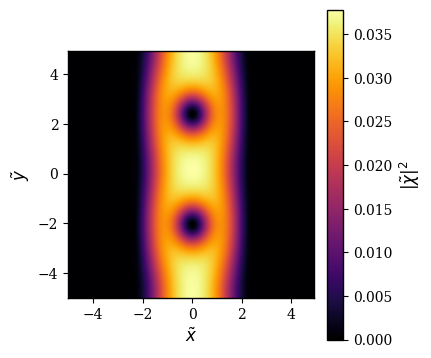

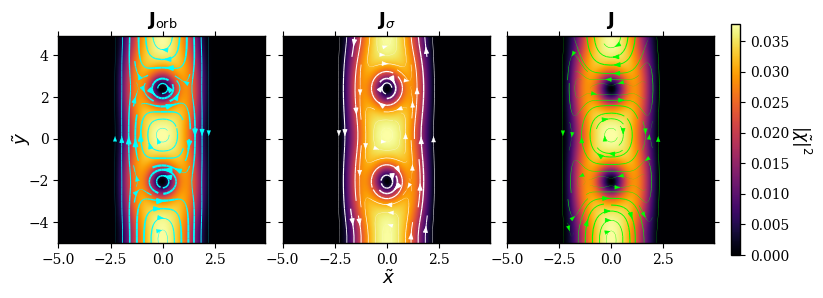

In [12]:
fig, ax = plt.subplots(figsize=(4.2, 3.6), constrained_layout=True)
im = plot_density(psi, grid, ax=ax)
fig.colorbar(im, ax=ax, label=r"$|\tilde{\chi}|^2$")
plt.show()

current_data = currents(psi, grid, params)
fig, axes = plot_current_panels(grid, current_data, filename=str(ROOT / "results" / "figures" / "current_panels_demo.png"))
plt.show()

